In [606]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import lightgbm as lgb
import shap
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import RobustScaler

In [285]:
# FUNCIONES

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/logistic-regression-project-tutorial/blob/main/README.es.md

Descripción de variables:

- age. Edad del cliente (numérico)

- job. Tipo de trabajo (categórico)

- marital. Estado civil (categórico)

- education. Nivel de educación (categórico)

- default. ¿Tiene crédito actualmente? (categórico)

- housing. ¿Tiene un préstamo de vivienda? (categórico)

- loan. ¿Tiene un préstamo personal? (categórico)

- contact. Tipo de comunicación de contacto (categórico)

- month. Último mes en el que se le ha contactado (categórico)

- day_of_week. Último día en el que se le ha contactado (categórico)

- duration. Duración del contacto previo en segundos (numérico)

- campaign. Número de contactos realizados durante esta campaña al cliente (numérico)

- pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)

- previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)

- poutcome. Resultado de la campaña de marketing anterior (categórico)

- emp.var.rate. Tasa de variación del empleo. Indicador trimestral (numérico)

- cons.price.idx. Índice de precios al consumidor. Indicador mensual (numérico)

- cons.conf.idx. Índice de confianza del consumidor. Indicador mensual (numérico)

- euribor3m. Tasa EURIBOR 3 meses. Indicador diario (numérico)

- nr.employed. Número de empleados. Indicador trimestral (numérico)

- y. TARGET. El cliente contrata un depósito a largo plazo o no (categórico)

In [286]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [287]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores unicos

In [288]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


## 1.2. Verificar valores duplicados

### 1.2.1. Filas

In [289]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 12 filas duplicadas


In [290]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].T

,1265,1266,12260,12261,14155,14234,16819,16956,18464,18465,...,25183,25217,28476,28477,32505,32516,36950,36951,38255,38281
age,39,39,36,36,27,27,47,47,32,32,...,39,39,24,24,35,35,45,45,71,71
job,blue-collar,blue-collar,retired,retired,technician,technician,technician,technician,technician,technician,...,admin.,admin.,services,services,admin.,admin.,admin.,admin.,retired,retired
marital,married,married,married,married,single,single,divorced,divorced,single,single,...,married,married,single,single,married,married,married,married,single,single
education,basic.6y,basic.6y,unknown,unknown,professional.course,professional.course,high.school,high.school,professional.course,professional.course,...,university.degree,university.degree,high.school,high.school,university.degree,university.degree,university.degree,university.degree,university.degree,university.degree
default,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
housing,no,no,no,no,no,no,yes,yes,yes,yes,...,no,no,yes,yes,yes,yes,no,no,no,no
loan,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
contact,telephone,telephone,telephone,telephone,cellular,cellular,cellular,cellular,cellular,cellular,...,cellular,cellular,cellular,cellular,cellular,cellular,cellular,cellular,telephone,telephone
month,may,may,jul,jul,jul,jul,jul,jul,jul,jul,...,nov,nov,apr,apr,may,may,jul,jul,oct,oct
day_of_week,thu,thu,thu,thu,mon,mon,thu,thu,thu,thu,...,tue,tue,tue,tue,fri,fri,thu,thu,tue,tue


In [291]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


### 1.2.2. Columnas

In [292]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.3. Verificar missing values

### 1.3.1. Datos enmascarados(categoricas)

In [293]:
#Datos enmascarados (variables categoricas)
columnas=df.select_dtypes(include='object').drop(columns="y", axis=1)
for col in columnas:
    print("-"*20)
    print(f"Columna: {col}")
    print("-"*20)
    print(df[col].value_counts(normalize=True)*100)

--------------------
Columna: job
--------------------
job
admin.           25.303575
blue-collar      22.471828
technician       16.366330
services          9.634253
management        7.101224
retired           4.172333
entrepreneur      3.536040
self-employed     3.451039
housemaid         2.574315
unemployed        2.462600
student           2.125024
unknown           0.801438
Name: proportion, dtype: float64
--------------------
Columna: marital
--------------------
marital
married     60.523120
single      28.084321
divorced    11.198271
unknown      0.194288
Name: proportion, dtype: float64
--------------------
Columna: education
--------------------
education
university.degree      29.541480
high.school            23.100835
basic.9y               14.680882
professional.course    12.725860
basic.4y               10.141830
basic.6y                5.563921
unknown                 4.201477
illiterate              0.043715
Name: proportion, dtype: float64
--------------------
Columna

Se aprecia como los valores nulos aparecen como: ``unknown`` y ``nonexistent``

In [294]:
# Reemplazamos y visualizamos categorias anteriores por NaN
df.replace(["unknown", "nonexistent"], np.nan, inplace=True)

### 1.3.2. Datos enmascarados(numericos)

In [295]:
df.select_dtypes(["int64", "float64"]).describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


<Axes: xlabel='pdays', ylabel='Count'>

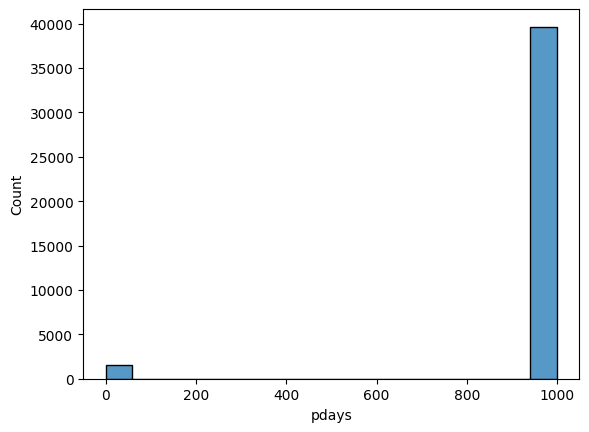

In [296]:
sns.histplot(data=df, x="pdays", bins="auto")

In [297]:
# Reemplazamos y visualizamos categorias anteriores por NaN
df["pdays"].replace(999, np.nan, inplace=True)

C:\Users\jjime\AppData\Local\Temp\ipykernel_11444\164245507.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["pdays"].replace(999, np.nan, inplace=True)


### 1.3.3. Visualización

In [298]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

job           0.801438
marital       0.194288
education     4.201477
default      20.876239
housing       2.404313
loan          2.404313
pdays        96.320672
poutcome     86.339130
dtype: float64

[]

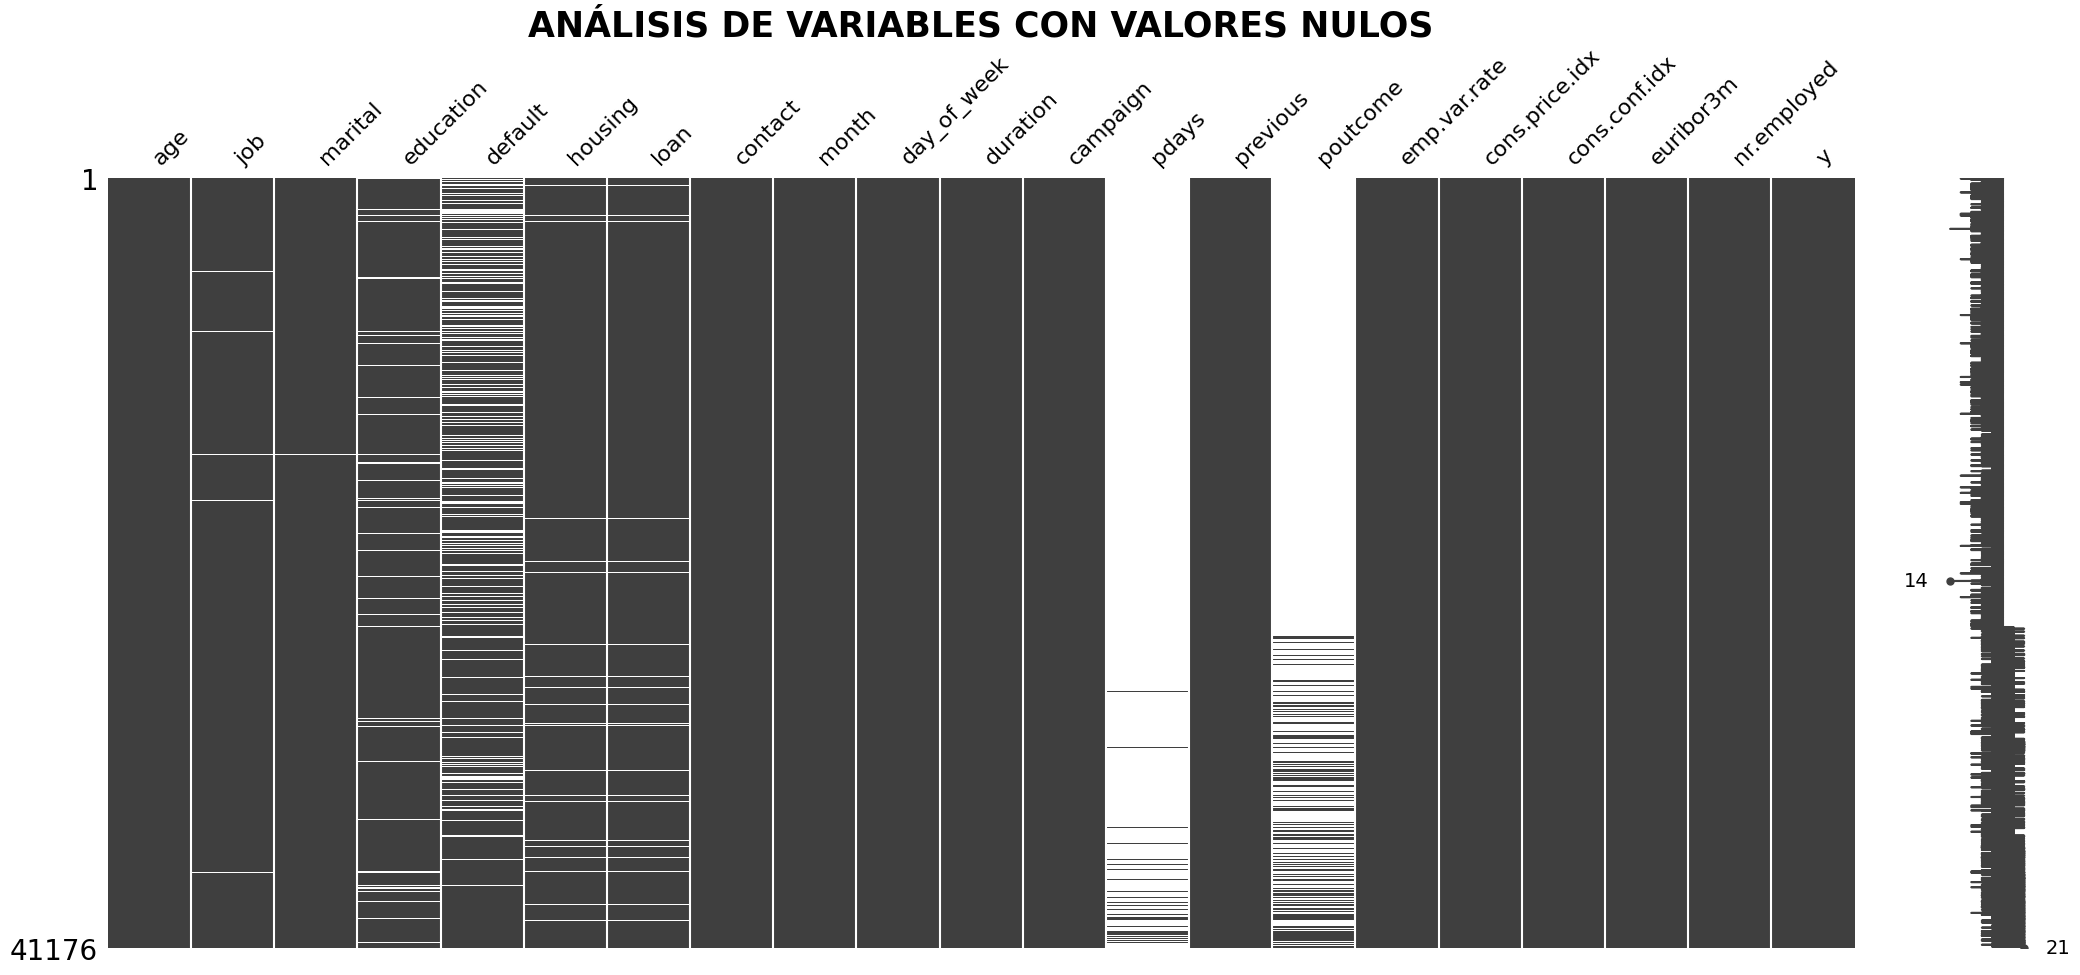

In [299]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

Como no hay columnas con más de un 40% de missing values, los valores faltantes que se observan será imputamos después de hcaer la división Train/Test.

### 1.3.4. Eliminación

Eliminaremos una fila o columna si presenta más de un 40% de sus datos como faltantes.

In [300]:
#Verificamos si hay filas con más de un 40% de missing values
column=df.isna().sum()/len(df)*100
print("No hay filas con muchas variables sin valores" if column[column>40].sum()==0 
      else f"Las columnas {column[column>40].index.to_list()} no aportan información")

Las columnas ['pdays', 'poutcome'] no aportan información


In [301]:
#Verificamos si hay filas con más de un 40% de missing values
filas=df.T.isna().sum()/len(df.T)*100
print("No hay filas con muchas variables sin valores" if filas[filas>40].sum()==0 
      else f"Hay {filas.sum()} filas con variables sin valores")

No hay filas con muchas variables sin valores


In [302]:
df.drop(columns=['pdays', 'poutcome'], axis=1, inplace=True)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,0,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,1.1,93.994,-36.4,4.857,5191.0,no


## 1.4. Codificar variables categoricas

Tipos de categoricas:

- Ordinal (hay orden implicito en los datos)
    - <u>Métodos</u>: ordinal encoding
- Nominal I (no hay orden, baja cardinalidad: 10 categorias)
    - <u>Métodos</u>: one hot encoding
- Nominal II (no hay orden, alta cardinalidad)
    - <u>Métodos</u>: proportion z test

In [303]:
# Visualizamos valores unicos y numero de categorías
for col in df.select_dtypes("object").drop(columns="y"):
    print(f"\n{'='*30}")
    print(f"COLUMNA: {col.upper()}")
    print(f"{'='*30}")
    
    # Valores únicos
    valores = df[col].dropna().unique() # → Elimina los NaN antes de obtener los valores únicos
    print(f"Número de categorías: {len(valores)}")
    print(f"Valores: {valores}\n")  


COLUMNA: JOB
Número de categorías: 11
Valores: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'entrepreneur' 'student']


COLUMNA: MARITAL
Número de categorías: 3
Valores: ['married' 'single' 'divorced']


COLUMNA: EDUCATION
Número de categorías: 7
Valores: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'university.degree' 'illiterate']


COLUMNA: DEFAULT
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: HOUSING
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: LOAN
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: CONTACT
Número de categorías: 2
Valores: ['telephone' 'cellular']


COLUMNA: MONTH
Número de categorías: 10
Valores: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


COLUMNA: DAY_OF_WEEK
Número de categorías: 5
Valores: ['mon' 'tue' 'wed' 'thu' 'fri']



In [304]:
onehot=[]
prop=[]

for col in df.select_dtypes("object").drop(columns="y"):
# Condicional para ordenar variables
    onehot.append(col) if df[col].nunique()<=5 else prop.append(col)  

print(f"Filas con menos de 5 categorias: {onehot}")
print(f"Filas con más de 5 categorias: {prop}")

Filas con menos de 5 categorias: ['marital', 'default', 'housing', 'loan', 'contact', 'day_of_week']
Filas con más de 5 categorias: ['job', 'education', 'month']


### 1.4.1. Menos de 5 categorias

#### A) **Y**

In [305]:
# Llamamos a la función
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=int) # drop='first' elimina una cat | sparse_output=False devuelve array

# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["y"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["y"])
y = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, y, on=df.index, how='right').drop(columns=["y", "key_0"]).rename(columns={"y_yes": "y"})
df["y"]

0        0
1        0
2        0
3        0
4        0
        ..
41171    1
41172    0
41173    0
41174    1
41175    0
Name: y, Length: 41176, dtype: int64

#### B) Marital

[]

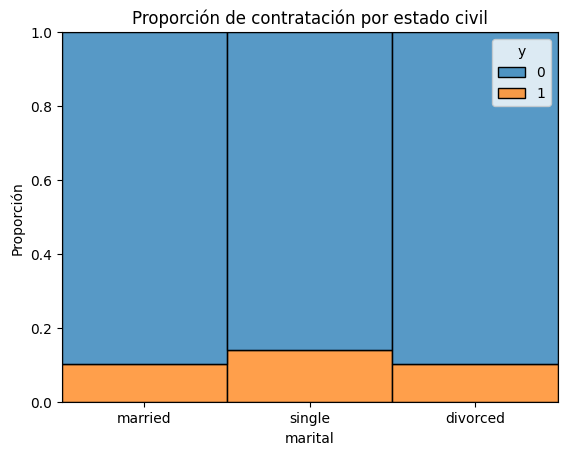

In [306]:
## Representacion
sns.histplot(data=df, x="marital", hue="y", multiple="fill")
plt.title("Proporción de contratación por estado civil")
plt.ylabel("Proporción")
plt.plot()

In [307]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["marital"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["marital"])
marital = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, marital, on=df.index, how='right').drop(columns=["marital", "marital_nan", "key_0"]).rename(columns={"marital_married": "maried", "marital_single": "single"})
df.columns

Index(['age', 'job', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y', 'maried', 'single'],
      dtype='object')

#### C) Default

In [308]:
#Testamos si la variable realmente es significativa
resumen=df.groupby("default")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
default,,,
no,32577,4196,0.128803
yes,3,0,0.000000


In [309]:
# unemployed y admin.
nobs=resumen["count"].to_list()
success=resumen["sum"].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

50.5424 %


[]

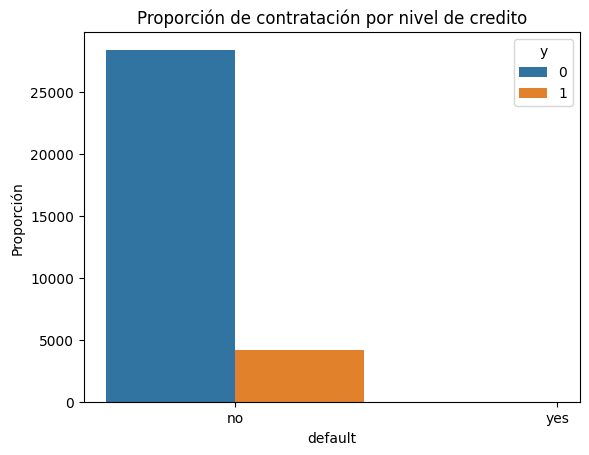

In [310]:
## Representacion
sns.countplot(data=df, x="default", hue="y")
plt.title("Proporción de contratación por nivel de credito")
plt.ylabel("Proporción")
plt.plot()

In [311]:
df.drop(columns="default", axis=1, inplace=True)

#### D) Housing

[]

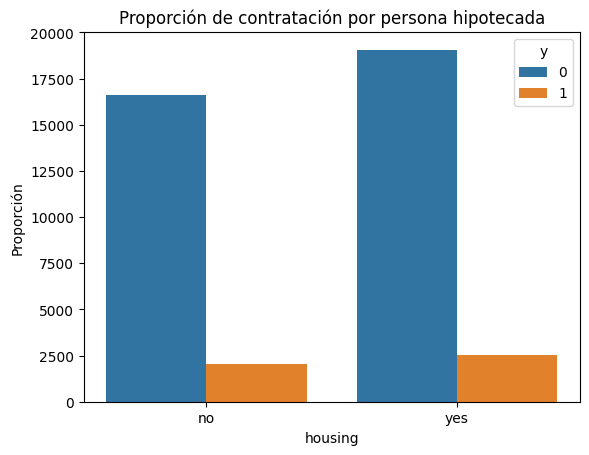

In [312]:
## Representacion
sns.countplot(data=df, x="housing", hue="y")
plt.title("Proporción de contratación por persona hipotecada")
plt.ylabel("Proporción")
plt.plot()

In [313]:
#Testamos si la variable realmente es significativa
resumen=df.groupby("housing")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
housing,,,
yes,21571,2507,0.116221
no,18615,2025,0.108783


In [314]:
# unemployed y admin.
nobs=resumen["count"].to_list()
success=resumen["sum"].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #A un 5% de significacia, variable importante (H1)

1.8754 %


In [315]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["housing"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["housing"])
housing = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, housing, on=df.index, how='right').drop(columns=["housing", "housing_nan", "key_0"]).rename(columns={"housing_yes": "housing"})
df["housing"].value_counts()

housing
1    21571
0    19605
Name: count, dtype: int64

#### E) Loan

[]

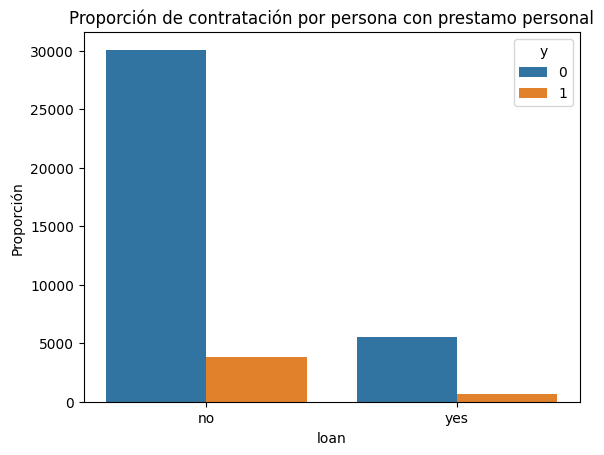

In [316]:
## Representacion
sns.countplot(data=df, x="loan", hue="y")
plt.title("Proporción de contratación por persona con prestamo personal")
plt.ylabel("Proporción")
plt.plot()

In [317]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["loan"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["loan"])
loan = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, loan, on=df.index, how='right').drop(columns=["loan", "loan_nan", "key_0"]).rename(columns={"loan_yes": "loan"})
df["loan"].value_counts()

loan
0    34928
1     6248
Name: count, dtype: int64

#### F) Contact

[]

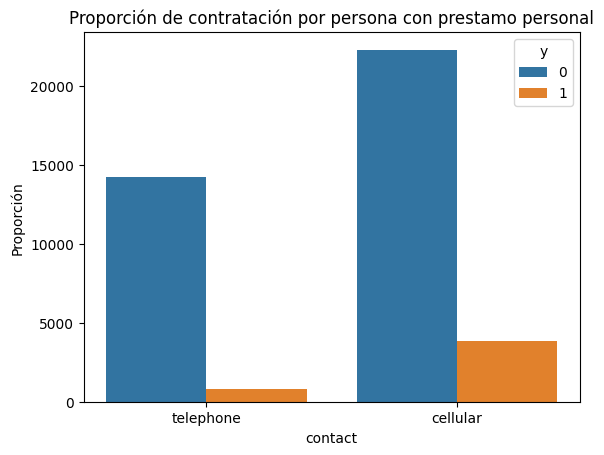

In [318]:
## Representacion
sns.countplot(data=df, x="contact", hue="y")
plt.title("Proporción de contratación por persona con prestamo personal")
plt.ylabel("Proporción")
plt.plot()

In [319]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["contact"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["contact"])
contact = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, contact, on=df.index, how='right').drop(columns=["contact", "key_0"]).rename(columns={"contact_telephone": "telephone"})
df["telephone"].value_counts()

telephone
0    26135
1    15041
Name: count, dtype: int64

#### G) Days_of_week

[]

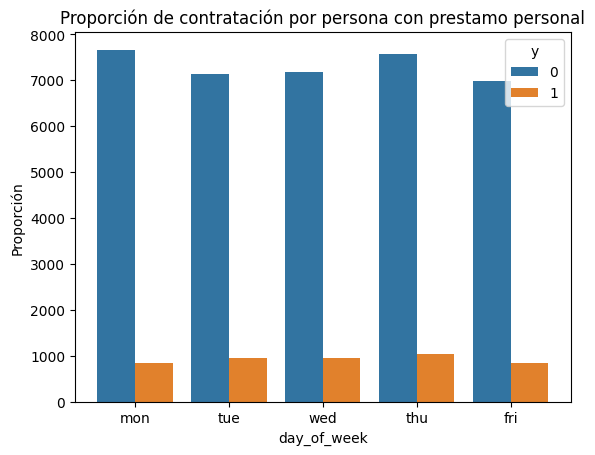

In [320]:
## Representacion
sns.countplot(data=df, x="day_of_week", hue="y")
plt.title("Proporción de contratación por persona con prestamo personal")
plt.ylabel("Proporción")
plt.plot()

In [321]:
#Diferencia de proporcion de cotratacion por dia
print(df.groupby("day_of_week")["y"].mean())

#Test chi2
tabla=pd.crosstab(df["day_of_week"], df["y"])
chi2,p,dof,expected=stats.chi2_contingency(tabla)
print("="*30)
print("Hay al menos diferencias de proporcion en un día" if p<0.01 else "No hay diferencia por dia")

day_of_week
fri    0.108101
mon    0.099507
thu    0.121142
tue    0.117858
wed    0.116671
Name: y, dtype: float64
Hay al menos diferencias de proporcion en un día


In [322]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["mon", "tue", "wed", "thu", "fri"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int)

# Transformamos
df["day_of_week"] = ordenc.fit_transform(df[["day_of_week"]])
df["day_of_week"].value_counts().sort_index()

day_of_week
0    8512
1    8086
2    8134
3    8618
4    7826
Name: count, dtype: int64

### 1.4.2. Más de 5 categorias

#### A) Month

[]

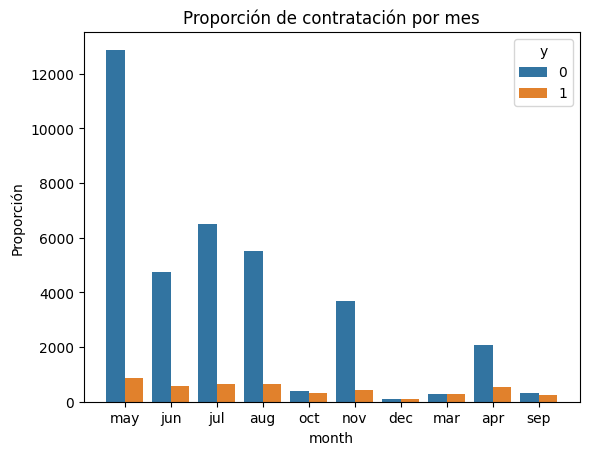

In [323]:
## Representacion
sns.countplot(data=df, x="month", hue="y")
plt.title("Proporción de contratación por mes")
plt.ylabel("Proporción")
plt.plot()

In [324]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int)

# Transformamos
df["month"] = ordenc.fit_transform(df[["month"]])
df["month"].value_counts().sort_index()

month
0      546
1     2631
2    13767
3     5318
4     7169
5     6176
6      570
7      717
8     4100
9      182
Name: count, dtype: int64

#### B) Educación

[]

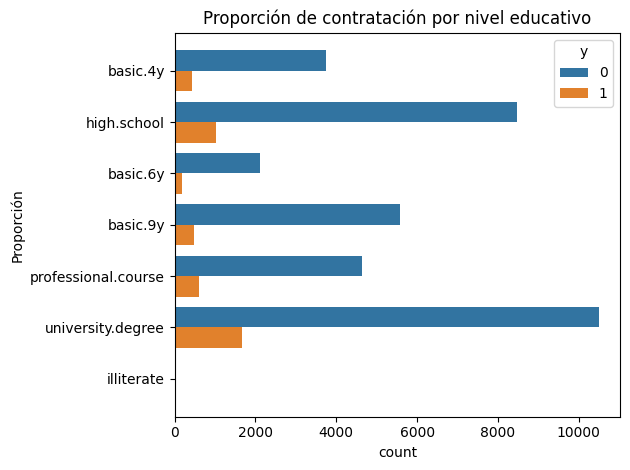

In [325]:
## Representacion
sns.countplot(data=df, y="education", hue="y")
plt.title("Proporción de contratación por nivel educativo")
plt.ylabel("Proporción")
plt.tight_layout()
plt.plot()

In [326]:
resumen=df.groupby("education")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
education,,,
illiterate,18,4,0.222222
university.degree,12164,1669,0.137208
professional.course,5240,595,0.113550
high.school,9512,1031,0.108389
basic.4y,4176,428,0.102490
basic.6y,2291,188,0.082060
basic.9y,6045,473,0.078246


In [327]:
# illiterate y basic 4y
nobs=[resumen["count"].iloc[0], resumen["count"].iloc[4]]
success=[resumen["sum"].iloc[0], resumen["sum"].iloc[4]]
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    df["education"].replace({"illiterate": "basic.4y"}, inplace=True)

9.5397 %


C:\Users\jjime\AppData\Local\Temp\ipykernel_11444\3776088727.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].replace({"illiterate": "basic.4y"}, inplace=True)


In [328]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["basic.4y", "basic.6y", "basic.9y", "high.school", "professional.course", "university.degree"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformamos
df["education"] = ordenc.fit_transform(df[["education"]])
df["education"].replace({-1: np.nan}, inplace=True)
df["education"].value_counts().sort_index()

C:\Users\jjime\AppData\Local\Temp\ipykernel_11444\1038695132.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].replace({-1: np.nan}, inplace=True)


education
0.0     4194
1.0     2291
2.0     6045
3.0     9512
4.0     5240
5.0    12164
Name: count, dtype: int64

#### C) Job

El hecho de que ``job`` sea una variable nominal con un importante numero de categorias, nos incita a no utilizar one hot encoding y hacer que la base de datos se sobredimensione. De esta forma, vamos a establecer un "orden artifical" con Ordered Target Encoding, aunque para evitar el *data leakage* los valores promedio de ``y`` que utilizaremos para dar orden a las categorías de ``job`` deben ser extraidos de train y copiados a test. Esto hace que test sea lo más imparcial posible.

## 1.5. División Train-Test

In [329]:
#Diviisón de la base de datos
X = df.drop('y',axis=1)
y = df['y']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) #random_state establece una semilla para que la division aleatoria sea la misma
X_train.head()

,age,job,education,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,maried,single,housing,loan,telephone
12346,29,entrepreneur,1.0,4,4,286,3,0,1.4,93.918,-42.7,4.959,5228.1,1,0,1,1,1
8564,50,admin.,5.0,3,2,178,6,0,1.4,94.465,-41.8,4.864,5228.1,0,1,0,0,1
21417,29,admin.,5.0,5,1,103,4,0,1.4,93.444,-36.1,4.963,5228.1,0,1,0,0,0
3315,35,admin.,5.0,2,3,135,1,0,1.1,93.994,-36.4,4.860,5191.0,0,1,0,0,1
33236,40,blue-collar,3.0,2,1,418,1,0,-1.8,92.893,-46.2,1.291,5099.1,0,1,0,0,0


### 1.5.1. Target Encoding

[]

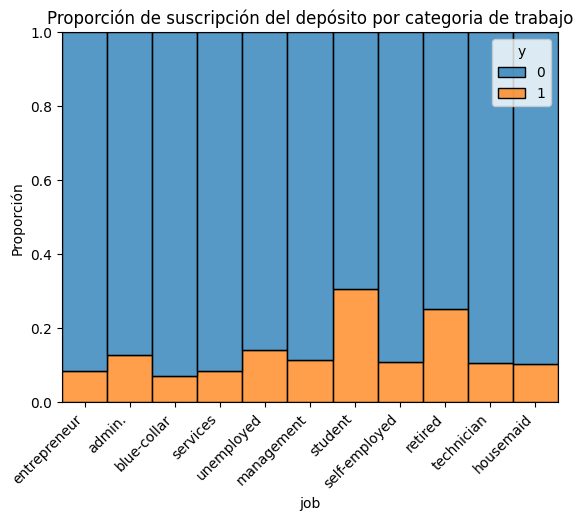

In [330]:
#Representacion gráfica
sns.histplot(x=X_train["job"], hue=y_train, multiple="fill") #multiple=fill expresa en procentajes
plt.title("Proporción de suscripción del depósito por categoria de trabajo")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha='right')
plt.plot()

In [331]:
#Tabla de contingencia
tabla=pd.crosstab(X_train["job"], y_train)

#Test de relación entre variables
chi2,p,dof,expected=stats.chi2_contingency(tabla) #El input para el test es la tabla de contingencias
print(round(p*100,4), "%") #Hay diferencias en al menos una categoria

0.0 %


In [332]:
var_ana=pd.merge(X_train["job"], y_train, on=y_train.index)
resumen=var_ana.groupby("job")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
resumen

,count,sum,mean
job,,,
student,682,208,0.304985
retired,1373,345,0.251275
unemployed,791,110,0.139064
admin.,8318,1062,0.127675
management,2362,269,0.113887
self-employed,1095,119,0.108676
technician,5399,563,0.104279
housemaid,868,88,0.101382
entrepreneur,1137,94,0.082674


Categorias con máximo un 1% de diferencia:

- unemployed y admin. 

- management y tetechnician

- housemaid y self-employed

- entrepreneur y services

In [333]:
# unemployed y admin.
nobs=resumen.iloc[2:4,0].to_list()
success=resumen.iloc[2:4,1].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    X_train["job"].replace({"unemployed": "unemploy-admin", "admin.": "unemploy-admin"}, inplace=True)

X_train["job"].unique()

36.0605 %


C:\Users\jjime\AppData\Local\Temp\ipykernel_11444\587409982.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["job"].replace({"unemployed": "unemploy-admin", "admin.": "unemploy-admin"}, inplace=True)


array(['entrepreneur', 'unemploy-admin', 'blue-collar', 'services',
       'management', 'student', 'self-employed', 'retired', 'technician',
       'housemaid', nan], dtype=object)

In [334]:
# management y technician
nobs=resumen.iloc[4:6,0].to_list()
success=resumen.iloc[4:6,1].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    X_train["job"].replace({"management": "manage-tech", "technician": "manage-tech"}, inplace=True)

X_train["job"].unique()

65.1611 %


array(['entrepreneur', 'unemploy-admin', 'blue-collar', 'services',
       'manage-tech', 'student', 'self-employed', 'retired', 'housemaid',
       nan], dtype=object)

In [335]:
# entrepreneur y services
nobs=resumen.iloc[8:10,0].to_list()
success=resumen.iloc[8:10,1].to_list()
z_stad,p=proportions_ztest(success, nobs)
print(round(p*100,4), "%") #H0: No hay diferencias

if p>0.01:
    X_train["job"].replace({"entrepreneur": "entrepre-service", "entrepreneur": "entrepre-service"}, inplace=True)

X_train["job"].unique()

96.0964 %


array(['entrepre-service', 'unemploy-admin', 'blue-collar', 'services',
       'manage-tech', 'student', 'self-employed', 'retired', 'housemaid',
       nan], dtype=object)

In [336]:
pd.merge(X_train["job"], y_train, on=y_train.index).drop(columns="key_0")

,job,y
0,entrepre-service,0
1,unemploy-admin,0
2,unemploy-admin,0
3,unemploy-admin,0
4,blue-collar,0
...,...,...
32935,blue-collar,0
32936,unemploy-admin,0
32937,retired,0
32938,manage-tech,0


In [337]:
var_ana=pd.merge(X_train["job"], y_train, on=y_train.index).drop(columns="key_0")
var_ana.groupby("job")["y"].mean().sort_values(ascending=False)

job
student             0.304985
retired             0.251275
unemploy-admin      0.128664
self-employed       0.108676
manage-tech         0.107203
housemaid           0.101382
entrepre-service    0.082674
services            0.082209
blue-collar         0.069368
Name: y, dtype: float64

In [338]:
# Definimos el orden haciendo uso del orden anterior
orden_inducido = ["blue-collar", "services", "entrepre-service", "housemaid", "manage-tech", "self-employed", "unemploy-admin", "retired", "student"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_inducido], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformamos train
X_train["job"] = ordenc.fit_transform(X_train[["job"]])
X_train["job"].replace({-1: np.nan}, inplace=True)
print(X_train["job"].unique())
print("="*35)

#Transformamos test
X_test["job"] = ordenc.fit_transform(X_test[["job"]])
X_test["job"].replace({-1: np.nan}, inplace=True)
print(X_test["job"].unique())

[ 2.  6.  0.  1.  4.  8.  5.  7.  3. nan]
[ 7.  0. nan  1.  3.  8.  5.]


C:\Users\jjime\AppData\Local\Temp\ipykernel_11444\130032882.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["job"].replace({-1: np.nan}, inplace=True)
C:\Users\jjime\AppData\Local\Temp\ipykernel_11444\130032882.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

## 1.6. Imputación missing values

De nuevo para evitar el data leakage vamos a rellenar los NaN del Test usando los valores en el Train.

In [339]:
X_train.isna().sum()[X_train.isna().sum()>0]/len(X_train)*100

job          0.834851
education    4.219794
dtype: float64

In [ ]:
#Instanciamos MissForest
categorical=["job", "education", "month", "day_of_week", "maried", "single", "housing", "loan", "telephone"]
imputer = MissForest(categorical=categorical)

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [05:03<00:00, 60.62s/it]
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fi

In [357]:
#Base de datos train
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index) #.fit_transform() entrena el modelo y predice los valores faltantes

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
100%|██████████| 5/5 [06:15<00:00, 75.18s/it]
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fi

In [358]:
#Base de datos test
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index) #.transform() aplica el modelo anterior en unos nuevos datos

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:490: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:494: UserWarning: In version 4.2.3, estimator fitting process is moved to `fit` method. `MissForest` will now imputes unseen missing values with fitted estimators with `transform` method. To retain the old behaviour, use `fit_transform` to fit the whole unseen data instead.
  warnings.warn(f"In version {VERSION}, estimator fitting process "
100%|██████████| 10/10 [00:12<00:00,  1.22s/it]


In [342]:
X_test_imp.isna().sum()[X_train.isna().sum()>0]/len(X_test)*100

job          0.0
education    0.0
dtype: float64

## 1.7. Análisis de outliers

In [343]:
X_train_imp.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32940.0,40.038039,10.428596,17.000,32.000,38.000,47.000,98.000
job,32940.0,3.503339,2.512899,0.000,1.000,4.000,6.000,8.000
education,32940.0,3.172556,1.649860,0.000,2.000,3.000,5.000,5.000
month,32940.0,3.612083,2.042961,0.000,2.000,3.000,5.000,9.000
day_of_week,32940.0,1.979053,1.409392,0.000,1.000,2.000,3.000,4.000
duration,32940.0,257.030662,258.127602,0.000,102.000,178.000,319.000,4918.000
campaign,32940.0,2.576290,2.784700,1.000,1.000,2.000,3.000,56.000
previous,32940.0,0.172313,0.494235,0.000,0.000,0.000,0.000,7.000
emp.var.rate,32940.0,0.083400,1.569619,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,32940.0,93.576831,0.578718,92.201,93.075,93.749,93.994,94.767


### 1.7.1. Isolation Forest

In [344]:
iso = IsolationForest(random_state=123)
df_num = X_train_imp.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train_imp)

In [345]:
df_num['outlier_flag'].value_counts(normalize=True)*100

outlier_flag
 1    59.338191
-1    40.661809
Name: proportion, dtype: float64

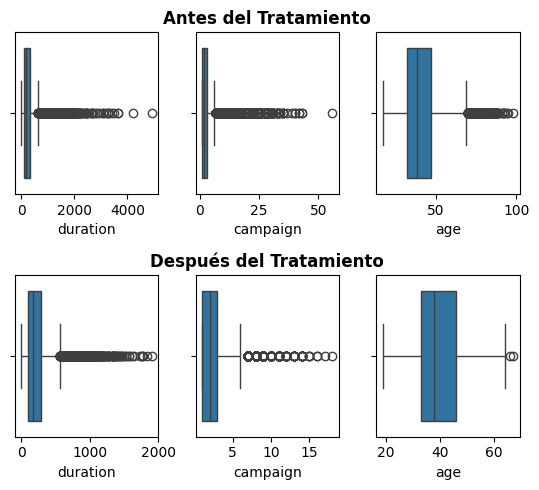

In [346]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(2, 3, figsize=(5.5, 5))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=df_num, x="duration", ax=axis[0,0])
sns.boxplot(data=df_num, x="campaign", ax=axis[0,1])
sns.boxplot(data=df_num, x="age", ax=axis[0,2])
axis[0,1].set_title("Antes del Tratamiento", fontweight="bold")
# Segunda fila
sns.boxplot(data=df_num[df_num['outlier_flag']==1], x="duration", ax=axis[1,0])
sns.boxplot(data=df_num[df_num['outlier_flag']==1], x="campaign", ax=axis[1,1])
sns.boxplot(data=df_num[df_num['outlier_flag']==1], x="age", ax=axis[1,2])
axis[1,1].set_title("Después del Tratamiento", fontweight="bold")


# Mostrar la figura
plt.tight_layout()
plt.show()

Pese a ver seleccionado las observaciones de IsolationForest sin riesgo de outliers que representan más de un 40% de la base de datos train, podemos observar que las variables ``duration`` y ``campaign`` siguen presentando un numero importante de outliers.

Para solucionarlo, optaremos por logaritmizar para comprimir sus escalas.

No obstante, en el caso especifico de ``duration`` es importante comprobar si los outliers causan dataleakage por el hecho de que una alta duracion implique el proceso de contratacion.

<Axes: ylabel='duration'>

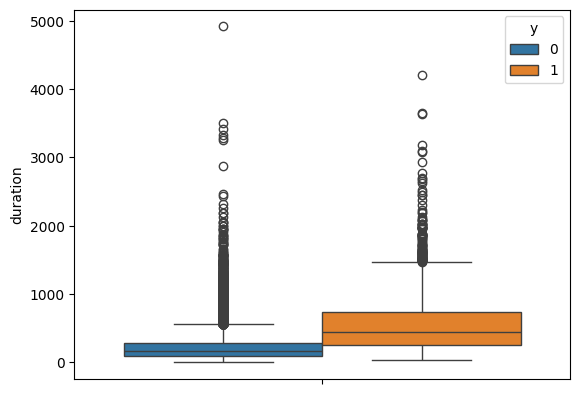

In [347]:
sns.boxplot(data=df_num, y="duration", hue=y_train)

### 1.7.2. Trimmed Mean

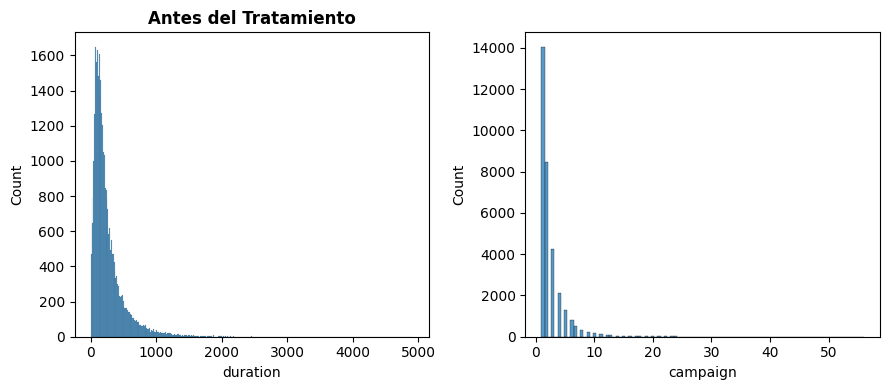

In [410]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(1, 2, figsize=(9, 4))

# Crear un histograma en el primer subplot
# Primera fila
sns.histplot(data=df_num, x="duration", ax=axis[0])
sns.histplot(data=df_num, x="campaign", bins=100, ax=axis[1])
axis[0].set_title("Antes del Tratamiento", fontweight="bold")

# Mostrar la figura
plt.tight_layout()
plt.show()

In [ ]:
print(f"- {len(dur_elm)+len(camp_elm)} observaciones eliminadas")
print(f"- {(len(dur_elm)+len(camp_elm))/len(X_train_imp)*100: 0.2f}% de la muestra train")

477 observaciones eliminadas
 1.45% de la muestra train


In [461]:
#Agregamos las base de datos train imputadas
df_tim=pd.merge(X_train_imp, y_train, on=y_train.index)

#Aplicamos trimmed mean:
## DURATION
sup_dur=df_tim["duration"].quantile(0.99) #solo p99 pues tenemos distribución asimétrica
### Topamos por >1 para evitar -inf cuando tomemos log
df_tim=df_tim[(df_tim["duration"]>1)&(df_tim["duration"]<sup_dur)]

# CONDICION CAMPAIGN
sup_cam=df_tim["campaign"].quantile(0.995) #p99.5 pues tenemos distribución asimétrica
df_tim=df_tim[(df_tim["campaign"]>0)&(df_tim["campaign"]<sup_cam)] #>1 para evitar -inf cuando tomemos log

#Observamos describe de las columnas eliminadas
## Duration
dur_elm=X_train_imp["duration"]
dur_elm=dur_elm[dur_elm>sup_dur]
print("ELIMINADOS DURATION\n",dur_elm.describe())
print("-"*30)
## Campaign
camp_elm=X_train_imp["campaign"]
camp_elm=camp_elm[camp_elm>sup_cam]
print("ELIMINADOS CAMPAIGN\n",camp_elm.describe())
print("="*30)
print(f"- {len(dur_elm)+len(camp_elm)} observaciones eliminadas")
print(f"- {(len(dur_elm)+len(camp_elm))/len(X_train_imp)*100: 0.2f}% de la muestra train")

ELIMINADOS DURATION
 count     329.000000
mean     1659.340426
std       499.545171
min      1259.000000
25%      1348.000000
50%      1488.000000
75%      1804.000000
max      4918.000000
Name: duration, dtype: float64
------------------------------
ELIMINADOS CAMPAIGN
 count    148.000000
mean      25.986486
std        6.044041
min       20.000000
25%       21.000000
50%       24.000000
75%       29.000000
max       56.000000
Name: campaign, dtype: float64
- 477 observaciones eliminadas
-  1.45% de la muestra train


c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\User

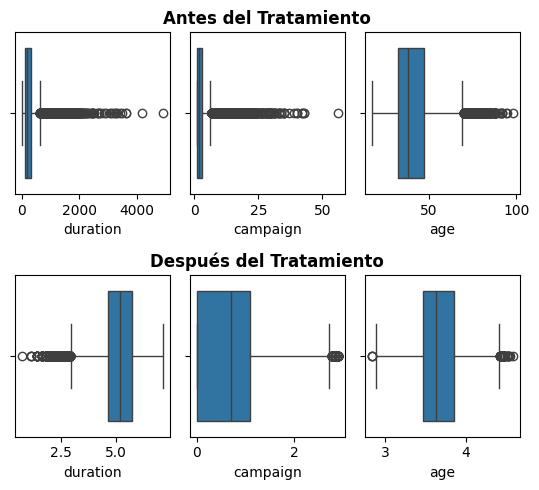

In [462]:
# Crear una figura con dos subplots (uno para el histograma y otro para el boxplot)
fig, axis = plt.subplots(2, 3, figsize=(5.5, 5))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train_imp, x="duration", ax=axis[0,0])
sns.boxplot(data=X_train_imp, x="campaign", ax=axis[0,1])
sns.boxplot(data=X_train_imp, x="age", ax=axis[0,2])
axis[0,1].set_title("Antes del Tratamiento", fontweight="bold")
# Segunda fila
sns.boxplot(data=np.log(df_tim), x="duration", ax=axis[1,0])
sns.boxplot(data=np.log(df_tim), x="campaign", ax=axis[1,1])
sns.boxplot(data=np.log(df_tim), x="age", ax=axis[1,2])
axis[1,1].set_title("Después del Tratamiento", fontweight="bold")

# Mostrar la figura
plt.tight_layout()
plt.show()

In [560]:
# Aplicamos trimmed mean method
df_filt=df_tim.copy()
## Aplicamos logaritmos en variables estudiadas con outliers
df_filt["duration"]=np.log(df_tim["duration"])
df_filt["campaign"]=np.log(df_tim["campaign"])
df_filt["age"]=np.log(df_tim["age"])

In [ ]:
#Dividimos caracteriticas de train
X_train_imp_filt=df_filt.drop(columns=["y", "key_0"])
y_train_filt=df_filt["y"]
X_train_imp_filt.describe()

,age,job,education,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,maried,single,housing,loan,telephone
count,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.000000,32435.00000
mean,3.657175,3.505997,3.174996,3.611993,1.976692,5.143520,0.638417,0.173455,0.075810,93.573718,-40.513874,3.613794,5166.725710,0.603823,0.281332,0.526098,0.152767,0.36476
std,0.253918,2.511560,1.650347,2.047035,1.409479,0.896656,0.670702,0.495902,1.571203,0.578701,4.634440,1.736238,72.430316,0.489110,0.449656,0.499326,0.359768,0.48137
min,2.833213,0.000000,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,3.465736,1.000000,2.000000,2.000000,1.000000,4.624973,0.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,3.637586,4.000000,3.000000,3.000000,2.000000,5.176150,0.693147,0.000000,1.100000,93.444000,-41.800000,4.857000,5191.000000,1.000000,0.000000,1.000000,0.000000,0.00000
75%,3.850148,6.000000,5.000000,5.000000,3.000000,5.746203,1.098612,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,1.000000,1.000000,1.000000,0.000000,1.00000
max,4.584967,8.000000,5.000000,9.000000,4.000000,7.135687,2.890372,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,1.000000,1.000000,1.000000,1.00000


In [609]:
# Aplicamos logaritmización en test
X_test_imp_filt=X_test_imp.copy()
X_test_imp_filt["duration"]=np.log(df_tim["duration"])
X_test_imp_filt["campaign"]=np.log(df_tim["campaign"])
X_test_imp_filt["age"]=np.log(df_tim["age"])

# **2. SELECCIÓN DE CARACTERÍSTICAS**

## 2.1. Aplicar métodos

### 2.1.1. Feature Importance

Trabajaremos con random forest

In [562]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_imp_filt, y_train_filt)

In [563]:
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100

# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train_imp_filt.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)

# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp


,feature,rf_importance,rf_importance_acum
5,duration,31.867758,31.867758
11,euribor3m,13.294214,45.161972
0,age,10.234371,55.396343
12,nr.employed,5.873627,61.269970
1,job,4.714811,65.984781
6,campaign,4.635711,70.620493
4,day_of_week,4.347075,74.967567
2,education,4.214167,79.181734
8,emp.var.rate,3.331919,82.513653
10,cons.conf.idx,2.831804,85.345457


### 2.1.2. Shuffle Importance

In [564]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_imp_filt, y_train_filt, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBClassifier(objective='binary:logistic', random_state=42).fit(X_train1, y_train1) #Gradient boosting

In [565]:
# En nuestro caso queremos minimizar los falsos positivos (clientes que realmente no compran)
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='precision') #https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names
## Extraemos los valores a un df
df_perm_imp = pd.DataFrame({'feature': X_train_imp_filt.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

,feature,perm_imp
5,duration,26.766982
8,emp.var.rate,23.298630
11,euribor3m,8.123605
12,nr.employed,4.185758
4,day_of_week,1.629236
17,telephone,1.387255
9,cons.price.idx,1.148313
3,month,0.933935
7,previous,0.632334
2,education,0.300204


### 2.1.3. SHAP

In [566]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1).fit(X_train1, y_train1) #Gradient boosting

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

100%|===================| 6476/6487 [00:27<00:00]        

In [567]:
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_train_imp_filt.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

,feature,shap_imp
5,duration,32.171217
8,emp.var.rate,31.341882
11,euribor3m,13.286453
12,nr.employed,6.058164
3,month,4.462673
9,cons.price.idx,2.501650
0,age,2.141033
6,campaign,1.685943
17,telephone,1.351784
2,education,1.095757


## 2.2. Seleccionar variables

In [568]:
#Añadimos resultados a un único df
df_importances = (
    df_rf_imp.drop(columns="rf_importance_acum")
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('perm_imp', ascending=False)

#Mostramos resultado
df_importances

,feature,rf_importance,perm_imp,shap_imp
5,duration,31.867758,26.766982,32.171217
7,emp.var.rate,3.331919,23.298630,31.341882
8,euribor3m,13.294214,8.123605,13.286453
14,nr.employed,5.873627,4.185758,6.058164
4,day_of_week,4.347075,1.629236,0.926431
17,telephone,1.225719,1.387255,1.351784
3,cons.price.idx,2.812068,1.148313,2.501650
13,month,2.113096,0.933935,4.462673
15,previous,2.462476,0.632334,0.514249
6,education,4.214167,0.300204,1.095757


In [572]:
# Eliminamos aquellas con un permutation importance negativo
df_filt=df_importances[(df_importances["rf_importance"]>1.5)&(df_importances["perm_imp"]>0)&(df_importances["shap_imp"]>1)]
df_filt

,feature,rf_importance,perm_imp,shap_imp
5,duration,31.867758,26.766982,32.171217
7,emp.var.rate,3.331919,23.298630,31.341882
8,euribor3m,13.294214,8.123605,13.286453
14,nr.employed,5.873627,4.185758,6.058164
3,cons.price.idx,2.812068,1.148313,2.501650
13,month,2.113096,0.933935,4.462673
6,education,4.214167,0.300204,1.095757


In [573]:
# Categorias eliminadas
df_importances["feature"][(df_importances["perm_imp"]<0)].to_list()

['cons.conf.idx', 'single', 'housing', 'campaign', 'maried', 'age', 'job']

In [594]:
# Categorias eliminadas dudosas
df_importances[(df_importances["perm_imp"]<0)&(df_importances["rf_importance"]>2)&(df_importances["shap_imp"]>2)]

,feature,rf_importance,perm_imp,shap_imp
0,age,10.234371,-0.539811,2.141033


In [575]:
# Caracteristicas seleccionadas
feature=df_filt["feature"].tolist()
feature

['duration',
 'emp.var.rate',
 'euribor3m',
 'nr.employed',
 'cons.price.idx',
 'month',
 'education']

## 2.3. Comprobar vif y correlaciones

In [576]:
# VIF
## Variable Xi: añdimos cte. para no sumir que regresión pasa por  (0,0)
x_vif=add_constant(X_train_imp_filt[feature])

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif[vif>5]

emp.var.rate      34.013053
euribor3m         39.532744
nr.employed       15.839490
cons.price.idx     5.096984
dtype: float64

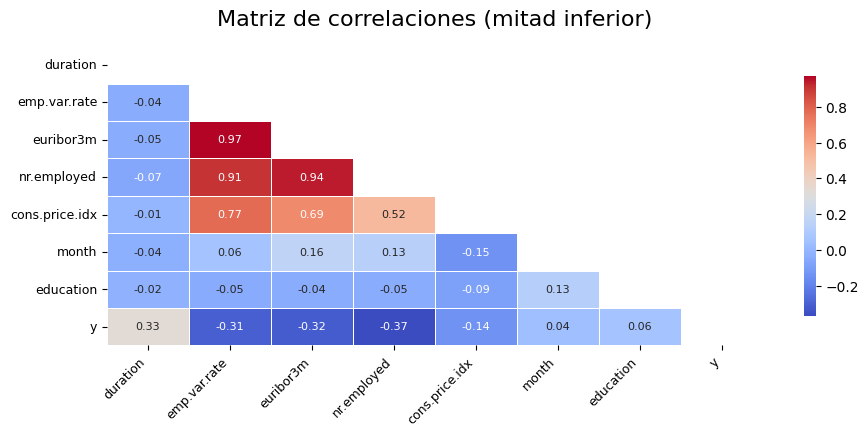

In [577]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['y'] = y_train_filt
corr = x_vif.corr()

#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

## 2.4. Cross_validation

Vamos a analizar las siguientes estrategias:

1. Dejamos todas las variables correlacionadas
2. Añadimos ``age``
3. Eliminamos ``emp.var.rate``
4. Eliminamos ``euribor3m``
5. Eliminamos ``cons.price.idx``

### A) Concreciones

In [611]:
#Scorings de análisis
scorings=["f1", "recall", "precision"] # scoring metrics: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names
#Resultados
metrics1=[]
# Versión 1: todas las características
met1_x=x_vif.drop(columns=["y"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met1_x, y_train_filt, cv=5, scoring=scoring)
    metrics1.append(float(round(cv_results1.mean()*100, 3)))

In [612]:
#Resultados
metrics2=[]
# Versión 2: añadimos "age"
met2_x=met1_x
met2_x["age"]=X_train_imp_filt["age"]

#Cross validation por cada scoring
for scoring in scorings:
    cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met2_x, y_train_filt, cv=5, scoring=scoring)
    metrics2.append(float(round(cv_results2.mean()*100, 3)))

In [613]:
#Resultados
metrics3=[]
# Versión 3: eliminamos "emp.var.rate"
met3_x=met2_x.drop(columns="emp.var.rate")

#Cross validation por cada scoring
for scoring in scorings:
    cv_results3 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met3_x, y_train_filt, cv=5, scoring=scoring)
    metrics3.append(float(round(cv_results3.mean()*100, 3)))

In [614]:
#Resultados
metrics4=[]
# Versión 4: eliminamos "euribor3m" 
met4_x=met2_x.drop(columns=["emp.var.rate", "euribor3m"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results4 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met4_x, y_train_filt, cv=5, scoring=scoring)
    metrics4.append(float(round(cv_results4.mean()*100, 3)))

In [615]:
#Resultados
metrics5=[]
# Versión 5: eliminamos "cons.price.idx" 
met5_x=met2_x.drop(columns=["emp.var.rate", "cons.price.idx"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results5 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met5_x, y_train_filt, cv=5, scoring=scoring)
    metrics5.append(float(round(cv_results5.mean()*100, 3)))

In [616]:
# Tabla resumen
pd.DataFrame([metrics1, metrics2, metrics3, metrics4, metrics5], index=["Df completo", " + Age", "+ Age, - emp.var.rate", "+ Age, - emp.var.rate, - euribor3m", "+ Age, - emp.var.rate, - cons.price.idx"], columns=scorings).sort_values(by="f1", ascending=False)

,f1,recall,precision
"+ Age, - emp.var.rate, - cons.price.idx",55.272,51.085,60.230
+ Age,55.021,50.767,60.078
"+ Age, - emp.var.rate",54.999,50.940,59.774
Df completo,52.433,49.812,55.358
"+ Age, - emp.var.rate, - euribor3m",52.333,48.540,56.823


A las características seleccionadas en el apartado anteriores, deberemos eliminar ``emp.var.rate``, ``cons.price.idx`` y añadir ``age``

In [617]:
final=X_train_imp_filt[['duration','euribor3m','nr.employed','month','education', "age"]]
final["y"]=y_train_filt
#Orden de las variables por correlacion con target
np.abs(final.corr().iloc[6]).sort_values(ascending=False).iloc[1:]

C:\Users\jjime\AppData\Local\Temp\ipykernel_11444\1253152737.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final["y"]=y_train_filt


nr.employed    0.367961
duration       0.328439
euribor3m      0.318039
education      0.060446
month          0.038604
age            0.006992
Name: y, dtype: float64

# 3. Modelado

# 3.1. Escalado de datos

https://scikit-learn.org/stable/api/sklearn.preprocessing.html

In [620]:
# Definimos características objetivo
## BBDD train
X_train_final=X_train_imp_filt[['duration','euribor3m','nr.employed','month','education', "age"]]
## BBDD test
X_test_final=X_test_imp_filt[['duration','euribor3m','nr.employed','month','education', "age"]]


# Visualizamos resultados
X_train_final.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,32435.0,5.143520,0.896656,0.693147,4.624973,5.176150,5.746203,7.135687
euribor3m,32435.0,3.613794,1.736238,0.634000,1.344000,4.857000,4.961000,5.045000
nr.employed,32435.0,5166.725710,72.430316,4963.600000,5099.100000,5191.000000,5228.100000,5228.100000
month,32435.0,3.611993,2.047035,0.000000,2.000000,3.000000,5.000000,9.000000
education,32435.0,3.174996,1.650347,0.000000,2.000000,3.000000,5.000000,5.000000
age,32435.0,3.657175,0.253918,2.833213,3.465736,3.637586,3.850148,4.584967


In [621]:
# Aplicamos robust scaler que es más eficiente para distribuciones no simétricas
## Instaciamos el escalador
rob_scal=RobustScaler()
## Ajustamos y transformamos para train
rob_scal.fit_transform(X_train_final)
## Solo transformamos para test (independia base datos)
rob_scal.fit_transform(X_test_final)

array([[            nan, -9.92811722e-01, -8.89922481e-01,
         0.00000000e+00,  3.33333333e-01,             nan],
       [ 7.35957132e-01, -9.83688139e-01, -7.12403101e-01,
        -3.33333333e-01, -3.33333333e-01, -1.42176658e+00],
       [            nan, -1.07768869e+00, -1.76279070e+00,
         1.33333333e+00,  3.33333333e-01,             nan],
       ...,
       [ 6.56481117e-01,  2.93060547e-02,  2.87596899e-01,
         3.33333333e-01,  6.66666667e-01, -6.93741818e-02],
       [-2.39415281e-01, -5.52944429e-04,  0.00000000e+00,
        -3.33333333e-01,  3.33333333e-01,  3.21566582e-01],
       [-7.95016736e-01,  2.82001659e-02,  2.87596899e-01,
         3.33333333e-01,  6.66666667e-01, -3.66998712e-01]],
      shape=(8236, 6))

## 3.2. Desarrollo del modelo

## 3.3. Evaluacion ajuste

In [ ]:
def get_metrics(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_auc = roc_auc_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_auc = roc_auc_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_auc = train_auc - test_auc
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy, train_f1, train_auc, train_precision, train_recall, train_specificity],[test_accuracy, test_f1, test_auc, test_precision, test_recall, test_specificity],[diff_accuracy, diff_f1, diff_auc, diff_precision, diff_recall, diff_specificity]],
                              columns = ['Accuracy', 'F1', 'AUC', 'Precision', 'Recall', 'Specificity'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

metrics_1 = get_metrics(yhat_logit, yhat_train1_pred, np.exp(y_train1))
metrics_1

## 3.4. Optimización de hiperparámetros

Hiper parámetros son los valores de configuracion del modelo:

penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression